In [9]:
# 1. 단어 사전 생성하기
from tensorflow.keras.preprocessing.text import Tokenizer

text = ["오늘 그만 지각을 해버렸네요", "맑은 날씨를 좋아합니다"]

tokenizer = Tokenizer(oov_token="<UMK>")
tokenizer.fit_on_texts(text)

voca_size = len(tokenizer.word_index) + 1

print(tokenizer.word_index)
print(voca_size)

{'<UMK>': 1, '오늘': 2, '그만': 3, '지각을': 4, '해버렸네요': 5, '맑은': 6, '날씨를': 7, '좋아합니다': 8}
9


In [10]:
# 2. 단어사전을 이용해서 문자를 숫자로 변경
new_text = ["오늘 그만 지각을 해버렸네요", "맑은 날씨를 좋아합니다.", "기분이 안좋네요"]
new_text_seq = tokenizer.texts_to_sequences(new_text)
new_text_seq

[[2, 3, 4, 5], [6, 7, 8], [1, 1]]

In [12]:
# 3. 숫자 값의 길이를 맞춤 pad
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 전체길이를 4로 맞추고 뒤쪽에 0으로 채움
new_text_pad = pad_sequences(new_text_seq, maxlen=4, padding="post")
new_text_pad

array([[2, 3, 4, 5],
       [6, 7, 8, 0],
       [1, 1, 0, 0]], dtype=int32)

In [14]:
# (n, 4) => (n, timestep, feature_dim)
# (n, 4, 1) 마지막 수치는 하이퍼파라미터
new_text_pad.shape

(3, 4)

In [16]:
# 4. 임베딩 => 토큰을 밀집 벡터로 변환하기 => 랜덤값인데 학습하면 비슷한 단어가 가까워짐
import tensorflow as tf
from tensorflow.keras.layers import Embedding, Input

inputs = Input(shape=(4,))

embedding_output = Embedding(input_dim=voca_size, output_dim=10)(inputs)

model = tf.keras.Model(inputs=inputs, outputs=embedding_output)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 4)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_1 (Embedding)         │ (None, 4, 10)          │            90 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 90 (360.00 B)

 Trainable params: 90 (360.00 B)

 Non-trainable params: 0 (0.00 B)

In [18]:
embedding_result = model.predict(new_text_pad)
embedding_result

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step


array([[[-0.00118994, -0.04542234,  0.02631751,  0.00664954,
          0.01315106, -0.0458586 , -0.03801881,  0.01933591,
         -0.00520166, -0.00585836],
        [ 0.04651568, -0.008222  , -0.02483549,  0.01586474,
         -0.00594393,  0.023359  ,  0.03769821, -0.0420749 ,
         -0.03173354,  0.0094463 ],
        [ 0.0180665 ,  0.00853724, -0.02329969, -0.0329598 ,
         -0.0040529 , -0.02847178,  0.04859518,  0.0082591 ,
          0.02624396, -0.0453296 ],
        [-0.03851985,  0.01687682, -0.03237367,  0.04138268,
          0.04526449, -0.04956677,  0.0155803 ,  0.04248716,
          0.02824784, -0.00689603]],

       [[-0.01934311, -0.0068483 ,  0.03361965, -0.00640738,
          0.00343563, -0.04468677,  0.0266439 ,  0.01218246,
         -0.04682568,  0.00732796],
        [ 0.01477355, -0.0155686 ,  0.00854765,  0.0312557 ,
          0.02703928, -0.0099614 ,  0.04308647,  0.01453637,
          0.02839709,  0.00328762],
        [ 0.01286012, -0.03510759, -0.04317873,  0

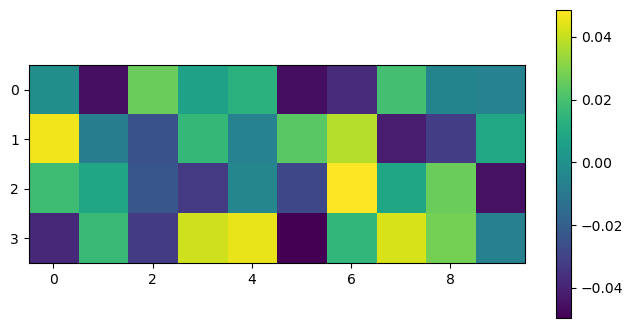

In [21]:
import matplotlib.pyplot as plt

sample = embedding_result[0]

plt.figure(figsize=(8,4))
plt.imshow(sample)
plt.colorbar()

In [1]:
# 감정분석 => 영화리뷰를 읽어서 긍정/부정인지 판별
import pandas as pd

train = pd.read_csv("http://114.207.245.181:13000/txt/ratings_train.txt", sep="\t")
test = pd.read_csv("http://114.207.245.181:13000/txt/ratings_test.txt", sep="\t")

In [30]:
train.tail(3)

,id,document,label
149997,9311800,이게 뭐요? 한국인은 거들먹거리고 필리핀 혼혈은 착하다?,0
149998,2376369,청춘 영화의 최고봉.방황과 우울했던 날들의 자화상,1
149999,9619869,한국 영화 최초로 수간하는 내용이 담긴 영화,0


In [31]:
test.tail(3)

,id,document,label
49997,9072549,그림도 좋고 완성도도 높았지만... 보는 내내 불안하게 만든다,0
49998,5802125,절대 봐서는 안 될 영화.. 재미도 없고 기분만 잡치고.. 한 세트장에서 다 해먹네,0
49999,6070594,마무리는 또 왜이래,0


In [32]:
train.columns

Index(['id', 'document', 'label'], dtype='object')

In [2]:
# na 인것은 삭제
train = train.dropna()
test = test.dropna()

train_texts = train['document'].to_list()
test_texts = test['document'].to_list()

train_labels = train['label'].to_list()
test_labels = test['label'].to_list()

train_texts[:3], train_labels[:3]

(['아 더빙.. 진짜 짜증나네요 목소리',
  '흠...포스터보고 초딩영화줄....오버연기조차 가볍지 않구나',
  '너무재밓었다그래서보는것을추천한다'],
 [0, 1, 0])

In [3]:
def clean_texts(texts, labels) :
    new_texts = []
    new_labels = []

    for t, l in zip(texts, labels):
        # 
        if t is not None and len(t.strip()) > 0:
            new_texts.append(t)
            new_labels.append(l)
    
    return new_texts, new_labels

train_texts, train_labels = clean_texts(train_texts, train_labels)
test_texts, test_labels = clean_texts(test_texts, test_labels)

In [4]:
# 단어 사전 생성하기
from tensorflow.keras.preprocessing.text import Tokenizer

tokenizer = Tokenizer(oov_token="<UMK>")
tokenizer.fit_on_texts(train_texts)

voca_size = len(tokenizer.word_index) + 1

In [9]:
tokenizer.word_index, voca_size

({'<UMK>': 1,
  '영화': 2,
  '너무': 3,
  '정말': 4,
  '진짜': 5,
  '이': 6,
  '그냥': 7,
  '왜': 8,
  '이런': 9,
  '더': 10,
  '수': 11,
  '영화를': 12,
  '다': 13,
  '잘': 14,
  '좀': 15,
  '보고': 16,
  'ㅋㅋ': 17,
  '그': 18,
  '영화는': 19,
  '영화가': 20,
  '본': 21,
  '봤는데': 22,
  '최고의': 23,
  '아': 24,
  '이건': 25,
  '내가': 26,
  '없는': 27,
  '없다': 28,
  '드라마': 29,
  '완전': 30,
  '이렇게': 31,
  '참': 32,
  '이거': 33,
  '평점': 34,
  '그리고': 35,
  '이게': 36,
  '좋은': 37,
  '있는': 38,
  '연기': 39,
  '내': 40,
  '평점이': 41,
  '보는': 42,
  '다시': 43,
  '스토리': 44,
  '역시': 45,
  '최고': 46,
  '쓰레기': 47,
  '난': 48,
  '많이': 49,
  'ㅋ': 50,
  '것': 51,
  'ㅋㅋㅋ': 52,
  '한': 53,
  'ㅠㅠ': 54,
  '재밌게': 55,
  '없고': 56,
  '또': 57,
  '하는': 58,
  '아깝다': 59,
  '꼭': 60,
  '보면': 61,
  '가장': 62,
  '마지막': 63,
  '뭐': 64,
  '영화다': 65,
  '무슨': 66,
  '하지만': 67,
  'ㅡㅡ': 68,
  'ㅎㅎ': 69,
  '10점': 70,
  '별로': 71,
  '같은': 72,
  '작품': 73,
  '솔직히': 74,
  '끝까지': 75,
  '볼': 76,
  '넘': 77,
  '안': 78,
  '대한': 79,
  '만든': 80,
  '와': 81,
  '봐도': 82,
  'ㅠ': 83,
  '전혀': 84,
  

In [5]:
x_train = tokenizer.texts_to_sequences(train_texts)
x_test = tokenizer.texts_to_sequences(test_texts)

In [6]:
x_train[:3]

[[24, 937, 5, 6728, 1098], [603, 6118, 72133, 72134, 7053, 31482], [72135]]

In [7]:
# 숫자 값의 길이를 맞춤 pad
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

x_train_pad = pad_sequences(x_train, maxlen=100, padding="post")
x_test_pad = pad_sequences(x_test, maxlen=100, padding="post")

x_train_pad = np.array(x_train_pad)
x_test_pad = np.array(x_test_pad)

x_train_pad.shape, x_test_pad.shape

((149995, 100), (49997, 100))

In [8]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense

model = tf.keras.Sequential([
    Input(shape=(100,)),
    Embedding(input_dim=voca_size, output_dim=128, mask_zero=True), # mask_zero=True : 0의 값은 패딩으로 처리
    LSTM(units=64, activation="tanh", dropout=0.3, recurrent_dropout=0.3),
    Dense(units=32, activation="relu"),
    Dense(units=1, activation="sigmoid")
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 100, 128)       │    37,927,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,979,457 (144.88 MB)

 Trainable params: 37,979,457 (144.88 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
y_train = np.array(train_labels)
y_test = np.array(test_labels)

y_train.shape, y_test.shape

((149995,), (49997,))

In [11]:
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(x_train_pad, y_train, epochs=5, verbose=1, validation_data=(x_test_pad, y_test))

Epoch 1/5
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 1134s 241ms/step - accuracy: 0.8038 - loss: 0.4063 - val_accuracy: 0.8326 - val_loss: 0.3630
Epoch 2/5
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 1265s 263ms/step - accuracy: 0.9461 - loss: 0.1466 - val_accuracy: 0.8061 - val_loss: 0.4477
Epoch 3/5
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 1210s 258ms/step - accuracy: 0.9809 - loss: 0.0569 - val_accuracy: 0.8055 - val_loss: 0.5103
Epoch 4/5
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 1208s 258ms/step - accuracy: 0.9889 - loss: 0.0318 - val_accuracy: 0.8012 - val_loss: 0.6576
Epoch 5/5
4688/4688 ━━━━━━━━━━━━━━━━━━━━ 1093s 233ms/step - accuracy: 0.9918 - loss: 0.0225 - val_accuracy: 0.8013 - val_loss: 0.8037


In [12]:
# 예측하기
sample = "이 영화는 진짜 재밌다"

seq = tokenizer.texts_to_sequences([sample])
padded = pad_sequences(seq, maxlen=100, padding="post")

# 0 ~ 1
model.predict(padded)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step


array([[0.97508883]], dtype=float32)